# Análise do banco de dados de gambás

## Imports das ferramentas/bibliotecas
Este bloco de código é responsável por fazer import das ferramentas e bibliotecas utilizadas e exibir o banco de dados para que póssamos analisar.

In [93]:
# Bibliotecas utilizadas no projeto
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Definição da variável para leitura do banco de dados
df = pd.read_csv("possum.xls")

# Exibição dos dados
df.head()
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   case      104 non-null    int64  
 1   site      104 non-null    int64  
 2   Pop       104 non-null    str    
 3   sex       104 non-null    str    
 4   age       102 non-null    float64
 5   hdlngth   104 non-null    float64
 6   skullw    104 non-null    float64
 7   totlngth  104 non-null    float64
 8   taill     104 non-null    float64
 9   footlgth  103 non-null    float64
 10  earconch  104 non-null    float64
 11  eye       104 non-null    float64
 12  chest     104 non-null    float64
 13  belly     104 non-null    float64
dtypes: float64(10), int64(2), str(2)
memory usage: 11.5 KB


Index(['case', 'site', 'Pop', 'sex', 'age', 'hdlngth', 'skullw', 'totlngth',
       'taill', 'footlgth', 'earconch', 'eye', 'chest', 'belly'],
      dtype='str')

## Limpeza e Tipagem dos dados

Na análise inicial do retorno de df.info(), obtemos um conjunto de dados estruturados com 104 registros e 14 variáveis. Para limpar, tratar e tipar os dados seguiremos os seguintes passos:

- **Remoção de identificadores(Ruído):** As colunas `case` (número do paciente) e `site` (local da captura) são variáveis de identificação categórica que foram lidas como números inteiros. Serão removidas do datased pois não possuem valor biométrico útil para o algorítimo de ML.

- **Conversão de Variáveis Categóricas:** Modelos de Regressão exigem entradas estritamente numéricas. Portanto, as variáveis `Pop` e `Sex`, classificadas como strings serão transformadas em colunas binárias (0 e 1).

In [94]:
# Remoção de identificadores que não têm valor biométrico
df = df.drop(columns=['case', 'site'])

# Transformação de texto ('Pop' e 'sex') em números (0 e 1)
df = pd.get_dummies(df, columns=['Pop', 'sex'], drop_first=True)

# Exibição dos dados
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        102 non-null    float64
 1   hdlngth    104 non-null    float64
 2   skullw     104 non-null    float64
 3   totlngth   104 non-null    float64
 4   taill      104 non-null    float64
 5   footlgth   103 non-null    float64
 6   earconch   104 non-null    float64
 7   eye        104 non-null    float64
 8   chest      104 non-null    float64
 9   belly      104 non-null    float64
 10  Pop_other  104 non-null    bool   
 11  sex_m      104 non-null    bool   
dtypes: bool(2), float64(10)
memory usage: 8.5 KB


### Caçando Outliers

O próximo passo para o tratamento e limpeza de dados é lidar com *outliers* (valores discrepantes que afetam a predição do algorítimo). Para isso, utilizaremos o **Bloxpot**, uma ótima ferramenta para localizar *outliers* visualmente.

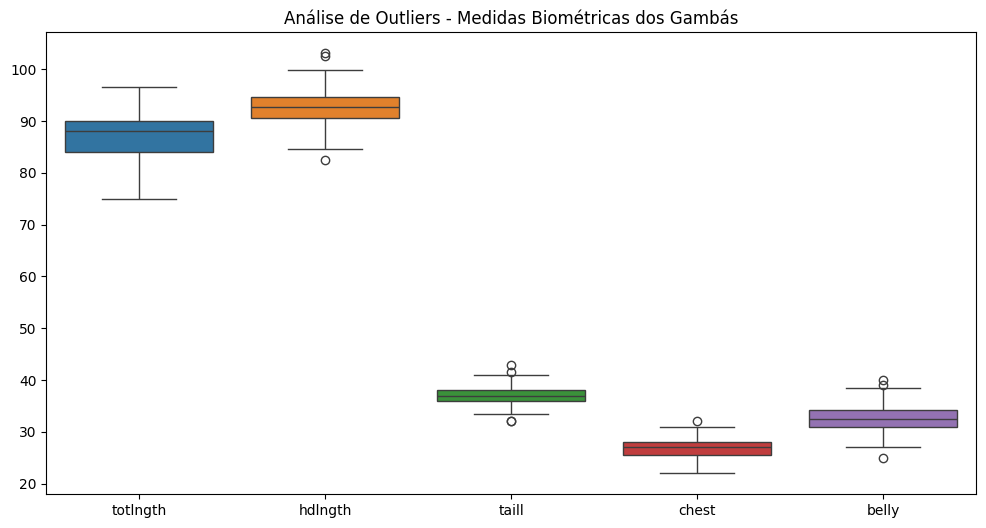

In [95]:
# Criação do Bloxpot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[['totlngth', 'hdlngth', 'taill', 'chest', 'belly']])
plt.title("Análise de Outliers - Medidas Biométricas dos Gambás")
plt.show()

### Analisando os Outliers
A partir do gráfico, podemos visualisar que há pouca quantidade de *outliers* e seus valores não são discrepantes e são aceitos dentro do contexto biométrico. Esses tipos de *outliers* são chamados de *outliers naturais*. Optaremos por mantê-los no banco de dados, pois seus valores não irão gerar desconfiança na inferência dos resultados do ML.

### Tratamento de Valores Nulos
Há ausência de dados em duas colunas: `age` com 2 nulos e `footlgth` com um nulo. Os nulos representam uma fração mínima(menos de 2%), portanto, opta-se pelo preenchimento dos dados nulos com a **média** (melhor que mediana nesse caso pela ausência de *outliers* fortes) dos dados de mesmo tipo. Isso preserva a distribuição sem distorcer a amostra ou descartar dados valiosos.

In [96]:
# Preenchendo os pouquíssimos nulos com a mediana
df['age'] = df['age'].fillna(df['age'].mean())
df['footlgth'] = df['footlgth'].fillna(df['footlgth'].mean())

## Análise Exploratória: Matriz de correlação

### Por que fazer uma matriz de correlação?
O objetivo desta etapa é identificar a força e a direção da relação linear entre as diferentes variáveis anatômicas. A matriz de correlação é a ferramenta que nos permite:
- **Definir a Variável Alvo:** Encontrar qual característica possui relações numéricas mais consistentes com as demais (ex: prever o comprimento total com base nas outras medidas do corpo).
- **Identificar Multicolinearidade:** Observar se duas características independentes variam sempre juntas (como o comprimento da cabeça e a largura do crânio), o que ajuda a entender as redundâncias do modelo.
- **Justificar o Modelo:** Provar com dados estruturados quais atributos terão maior ou menor peso na tomada de decisão da Regressão Linear.

**Como funciona?**
A análise utiliza o **Coeficiente de Correlação de Pearson ($r$)**, que quantifica a dependência linear entre duas variáveis. O valor de $r$ é sempre posicionado no intervalo $-1 \le r \le 1$:
* **Próximo a $1$:** Forte correlação positiva (ambas as variáveis crescem juntas).
* **Próximo a $-1$:** Forte correlação negativa (variáveis são inversamente proporcionais).
* **Próximo a $0$:** Nenhuma relação linear estatisticamente relevante.

**Como será feito?**
Em termos de código, aplicaremos o método `.corr()` da biblioteca `pandas` sobre o *DataFrame* previamente limpo. Para facilitar a extração de *insights* e documentar os resultados de forma visual, os valores dessa matriz serão plotados em um Mapa de Calor (*Heatmap*) utilizando a biblioteca `seaborn`.

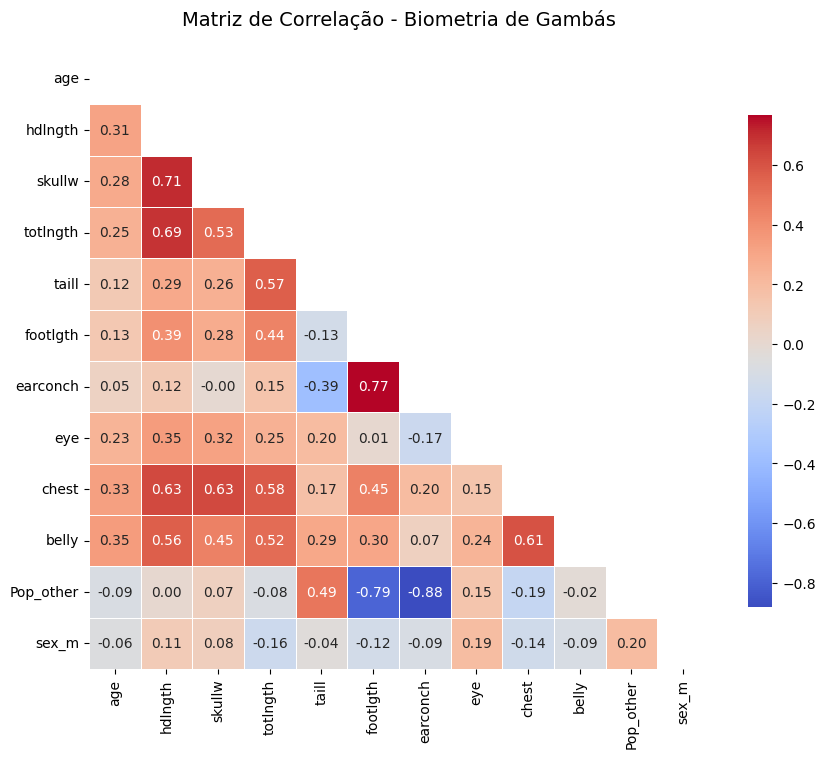

In [97]:
# Variável guarda matriz de correlação
corr = df.corr()

# Criamos a máscara para o triângulo superior usando o Numpy
# np.ones_like cria uma grade falsa, e np.triu recorta no formato de triângulo
# Processo importânte para evitar repetição de dados desnecssários

mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))

# Ajuste do visual
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", 
            linewidths=0.5, cbar_kws={"shrink": .8})

plt.title("Matriz de Correlação - Biometria de Gambás", fontsize=14, pad=20)
plt.show()

# Interpretando a matriz

- **Multicolinearidade:** As variáveis `hdlngth`, `skullw`, `totlngth`, `chest` e `belly` tem forte correlação. Isso significa que elas carregam informação muito parecida.
- **Redundância:** `footlgth` e `earconch` são muito parecidas.
- **Pop_other é o preditor mais forte:** Suas correlações negativas com `footlgth`(-0.79) e `earconch`(-0.88) são as mais altas da matriz. Isso sugere diferença morfológica clara. Excelente para classificação de grupo ou clustering.
- **Proporções corporais para o sexo do animal são semelhantes:** 

## Gráfico de dispersão (Scatter Plot)
Para confirmar a forte redundância encontrada na matriz entra a população geográfica (`Pop_other`) e o tamanho do pé e da orelha geramos um gráfico de dispersão.


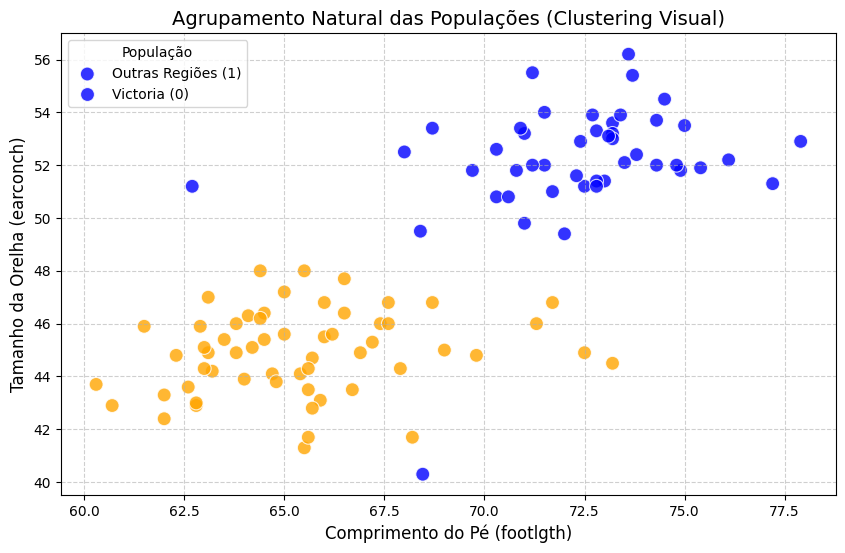

In [98]:
plt.figure(figsize=(10, 6))

# s=100 aumenta o tamanho das bolinhas, alpha=0.8 deixa elas levemente transparentes
sns.scatterplot(data=df, x='footlgth', y='earconch', hue='Pop_other', 
                palette={0: 'blue', 1: 'orange'}, s=100, alpha=0.8)

#títulos e rótulos
plt.title("Agrupamento Natural das Populações (Clustering Visual)", fontsize=14)
plt.xlabel("Comprimento do Pé (footlgth)", fontsize=12)
plt.ylabel("Tamanho da Orelha (earconch)", fontsize=12)

# legenda
plt.legend(title='População', labels=['Outras Regiões (1)', 'Victoria (0)'])
plt.grid(True, linestyle='--', alpha=0.6)

# Exibir gráfico
plt.show()

O resultado visual comprova a grande separação biológica. Os dados formam dois *clusters* quase perfeitamente distintios. Isso indica que o tamanho da orelha varia grandemente para gambás de diferentes regiões. Eu poderia fazer um modelo que infere se um gambá é de Victória ou não de acordo com o tamanho da orelha e comprimento do pé, mas seria um modelo muito simplório.

## Random Forest
Com a intenção de lidar com a **multicolinearidade** demonstrada na matriz de correlação e também poder fazer predições para várias variáveis, foi escolhido o modelo de predição **Random Forest**. 
Diferente da **Regressão Linear**, que tenta traçar uma única reta e sofre com dados correlacionados, o **Random Forest** constrói múltiplas **Árvores de Decisão simultâneas**. Ele consegue capturar relações não-lineares complexas e decidir de forma mais autônoma quais características biológicas são realmente importantes para prever o comprimento total (`totlngth`), mitigando o ruído das variáveis redundantes.


--- Random Forest ---
TREINO -> R²: 0.9517  |  RMSE: 0.99 cm
TESTE  -> R²: 0.4102  |  RMSE: 2.56 cm


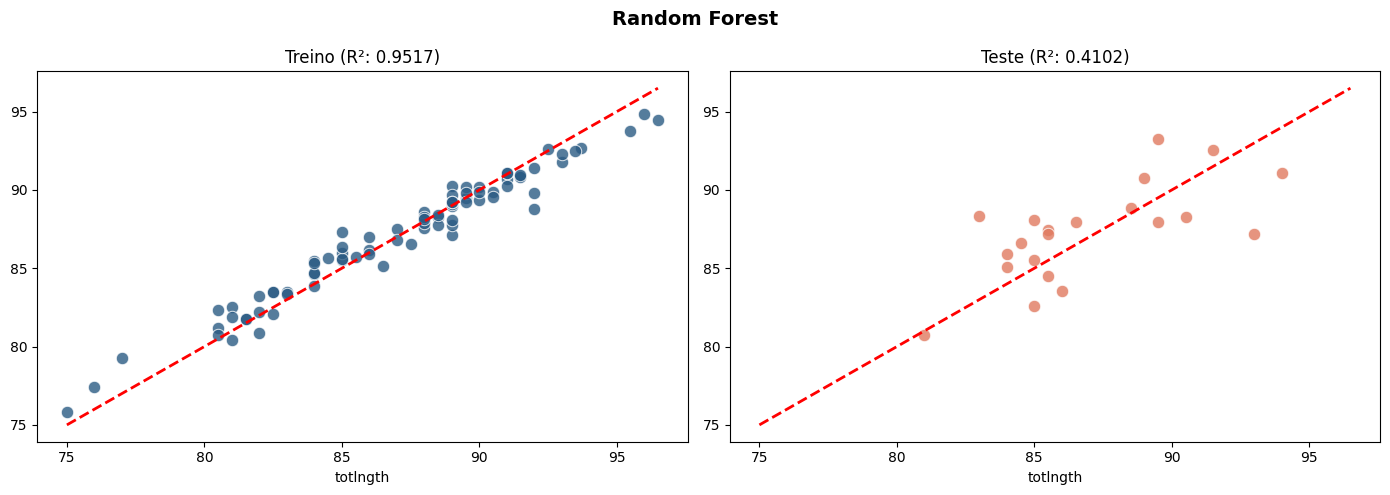

In [99]:
# Função de execução para ser reutilizada em mais testes
def executar_pipeline(modelo, X, y, titulo):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    modelo.fit(X_train, y_train)
    
    y_pred_train = modelo.predict(X_train)
    y_pred_test = modelo.predict(X_test)
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    print(f"\n--- {titulo} ---")
    print(f"TREINO -> R²: {r2_train:.4f}  |  RMSE: {rmse_train:.2f} cm")
    print(f"TESTE  -> R²: {r2_test:.4f}  |  RMSE: {rmse_test:.2f} cm")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(titulo, fontsize=14, fontweight='bold')

    sns.scatterplot(x=y_train, y=y_pred_train, ax=axes[0], color='#2b5b84', s=80, alpha=0.8)
    axes[0].plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2)
    axes[0].set_title(f"Treino (R²: {r2_train:.4f})")
    
    sns.scatterplot(x=y_test, y=y_pred_test, ax=axes[1], color='#e07a5f', s=80, alpha=0.8)
    axes[1].plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--', linewidth=2)
    axes[1].set_title(f"Teste (R²: {r2_test:.4f})")

    plt.tight_layout()
    plt.show()

# Definição do alvo geral
y = df['totlngth']

# Execução do teste
X_rf1 = df.drop(columns=['totlngth'])
modelo_rf1 = RandomForestRegressor(n_estimators=100, random_state=42)

executar_pipeline(modelo_rf1, X_rf1, y, "Random Forest")

## Overfitting
Podemos observar que o R² (coeficiente de determinação) para os treinos é mais do que o dobro para o teste real. Um gap de mais de 0.5, isto altíssimo. O nome desse fênomeno se chama *overfitting*, é como se o modelo "decorasse" os dados ao invés de aprender o padrão, causando descrepância para lidar com dados reais.

### Como resolver?
Há várias estratégias. Antes de tomar uma decisão, vamos analisar o peso de cada variável no algorítimo.

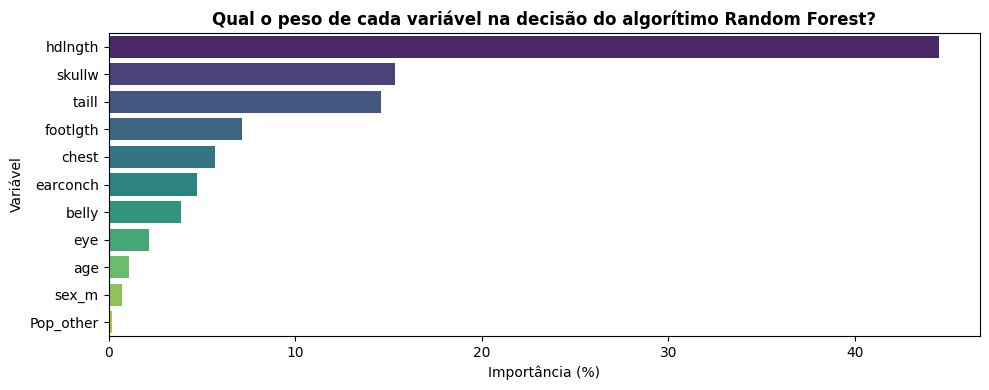

In [100]:
# Criação de gráfico que demonstra peso das variáveis
importancia_rf = pd.DataFrame({
    'Variável': X_rf1.columns, 
    'Importância (%)': modelo_rf1.feature_importances_ * 100
}).sort_values(by='Importância (%)', ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(data=importancia_rf, x='Importância (%)', y='Variável', hue='Variável', palette='viridis', legend=False)
plt.title("Qual o peso de cada variável na decisão do algorítimo Random Forest?", fontweight='bold')
plt.tight_layout()
plt.show()

## Análise dos pesos
Observa-se que apenas 3 variáveis (`hdlngth`, `skullw` e `tail`) tem forte influência nas decisões do algoritmo. Portanto, vamos tentar "podar" o Random Forest eliminado estas variáveis para ver o que acontece.


--- Random Forest com poda ---
TREINO -> R²: 0.9356  |  RMSE: 1.14 cm
TESTE  -> R²: 0.2662  |  RMSE: 2.85 cm


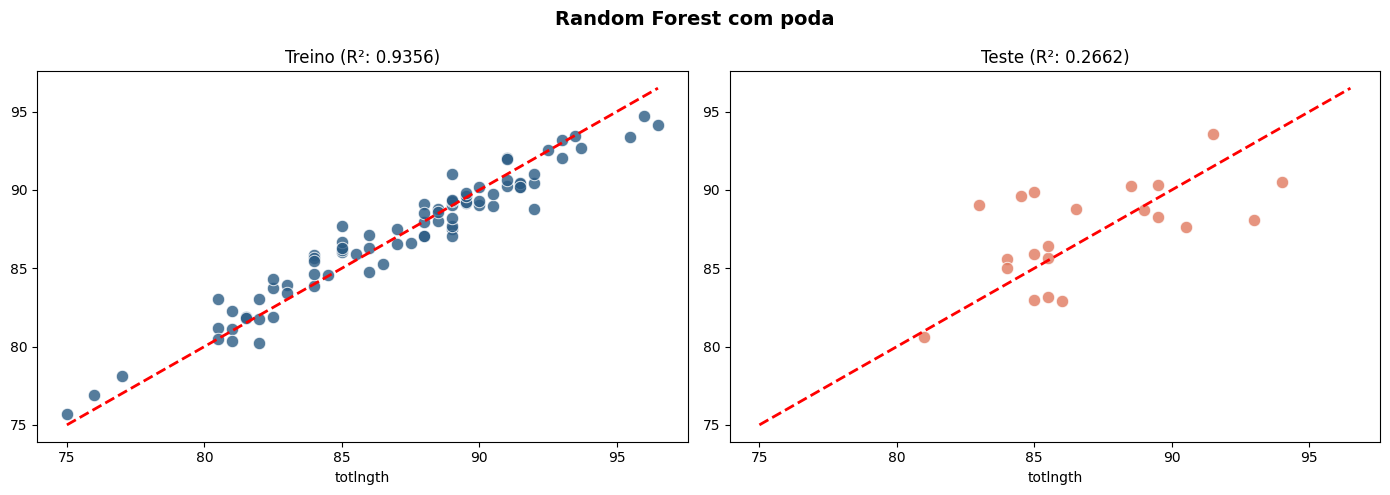

In [101]:
# Random Forest (Podado)
colunas_poda_extrema = ['totlngth', 'footlgth' , 'chest', 'belly', 'Pop_other', 'age', 'eye', 'sex_m', 'earconch']
X_rf2 = df.drop(columns=colunas_poda_extrema, errors='ignore')

modelo_rf2 = RandomForestRegressor(n_estimators=100, random_state=42)

# Chamada da função anterior
executar_pipeline(modelo_rf2, X_rf2, y, "Random Forest com poda")

## Analisando resultado
Como podemos ver, nossa estratégia aumentou ainda mais o *overfitting*. Vamos tentar uma outra maneira.

## Regressão Ridge
Existem modelos que conseguem lidar melhor com a **multicolinearidade** e grande diferença de pesos entre variáveis ao mesmo tempo. A **Regressão Ridge** é um desses modelos. Este algorítimo "puxa" os coeficientes para valores menores e mais estáveis sem zerá-los, ao mesmo tempo que reduz o impacto das menos relevantes com um algoritmo de penalização. Vamos aplicá-la e analisar.


--- Regressão Ridge ---
TREINO -> R²: 0.7789  |  RMSE: 2.12 cm
TESTE  -> R²: 0.3182  |  RMSE: 2.75 cm


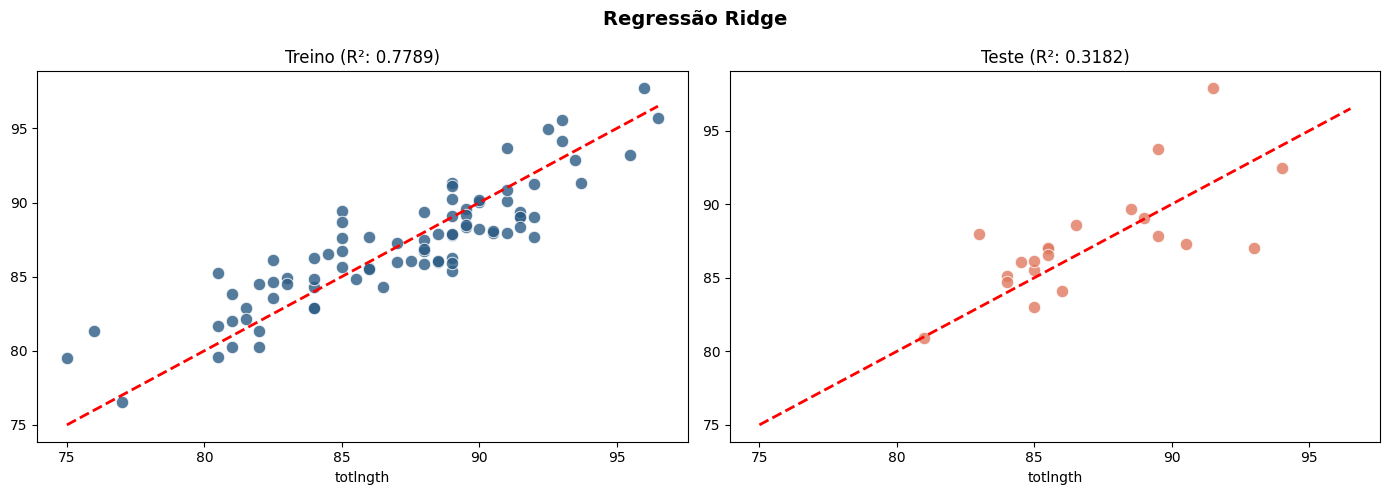

In [102]:
# Regressão Ridge (Poda Linear)
colunas_poda_linear = ['totlngth', 'age', 'eye', 'sex_m', 'earconch'] 
X_ridge = df.drop(columns=colunas_poda_linear, errors='ignore')

modelo_ridge = Ridge(alpha=10.0, random_state=42)

# Chamanda da função
executar_pipeline(modelo_ridge, X_ridge, y, "Regressão Ridge")

## Análise do resultado
Podemos observar que obtivemos melhores no *overfitting*, embora o mesmo continue elevado. Provavelmente, pela população de gambás do banco de dados ser muito baixa (104), não é possível obter resultados muito superiores a isso. Ainda sim é interessante observar como o modelo correto aplicado ao caso, após uma análise da situalçao, certo traz resultados melhores. O **RMSE** final nos testes foi de 2.75cm, ou seja, o algorítimo erra o tamanho real da coluna do gambá por aproximadamente 2.75cm, o que não é um número elevado.